# 📉 Class 11.2 — Simple Moving Average & Holt-Winters
### 301 – ML Techniques | Week 11

**Learning Goals:** Implement SMA forecasting, apply Exponential Triple Smoothing (Holt-Winters), plot with confidence intervals, evaluate MAE vs naive baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (13, 5)
print('✅ Ready')
from statsmodels.tsa.holtwinters import ExponentialSmoothing

✅ Ready


Sales series: 84 months
Train: 67 months | Test: 17 months

⚠️  REMINDER: split is chronological — train is BEFORE test in time


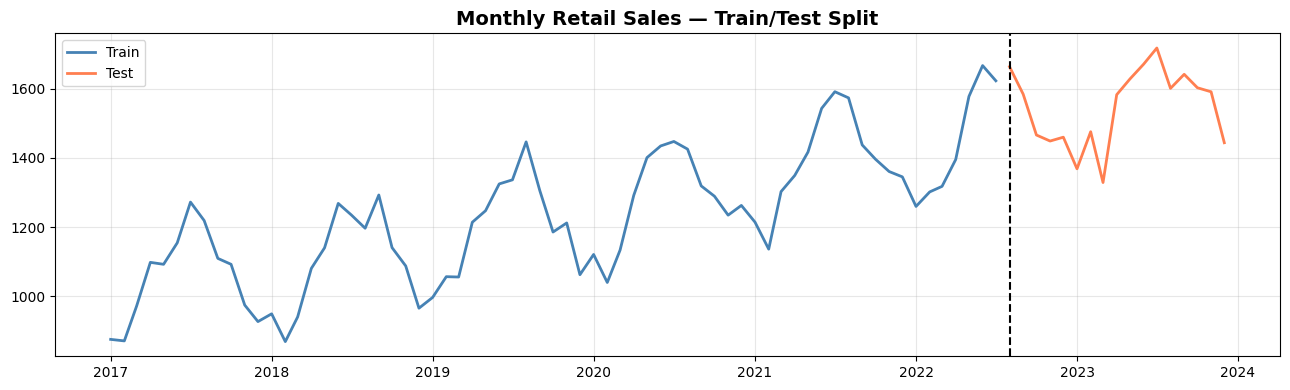

In [2]:
# Monthly retail sales (synthetic)
np.random.seed(42)
n = 84  # 7 years monthly
dates = pd.date_range('2017-01', periods=n, freq='MS')
trend = np.linspace(1000, 1600, n)
season= 150 * np.sin(2*np.pi*np.arange(n)/12 - np.pi/2)
noise = np.random.normal(0, 50, n)
sales = pd.Series(trend + season + noise, index=dates, name='Sales')
print(f'Sales series: {n} months')

# CRITICAL: Chronological split — 80/20
split_idx = int(n * 0.8)
train = sales.iloc[:split_idx]
test  = sales.iloc[split_idx:]
print(f'Train: {len(train)} months | Test: {len(test)} months')
print()
print('⚠️  REMINDER: split is chronological — train is BEFORE test in time')

plt.figure(figsize=(13, 4))
plt.plot(train.index, train, color='steelblue', linewidth=2, label='Train')
plt.plot(test.index,  test,  color='coral',     linewidth=2, label='Test')
plt.axvline(test.index[0], color='black', linestyle='--', linewidth=1.5)
plt.title('Monthly Retail Sales — Train/Test Split', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [3]:
# Simple Moving Average forecasts
from sklearn.metrics import mean_absolute_error

def sma_forecast(train, test, window):
    """Forecast using rolling mean. Last window values predict each test point."""
    history = list(train)
    preds   = []
    for _ in range(len(test)):
        preds.append(np.mean(history[-window:]))
        history.append(preds[-1])
    return np.array(preds)

for window in [3, 6, 12]:
    preds = sma_forecast(train, test, window)
    mae   = mean_absolute_error(test, preds)
    print(f'SMA window={window:2d}: MAE = {mae:.1f}')

SMA window= 3: MAE = 105.8
SMA window= 6: MAE = 103.8
SMA window=12: MAE = 118.7


=== Forecast Accuracy Comparison ===
  Naive (last value): MAE = 101.9
  SMA (window=12)   : MAE = 118.7
  Holt-Winters (add): MAE = 43.5
  Holt-Winters (mul): MAE = 54.0


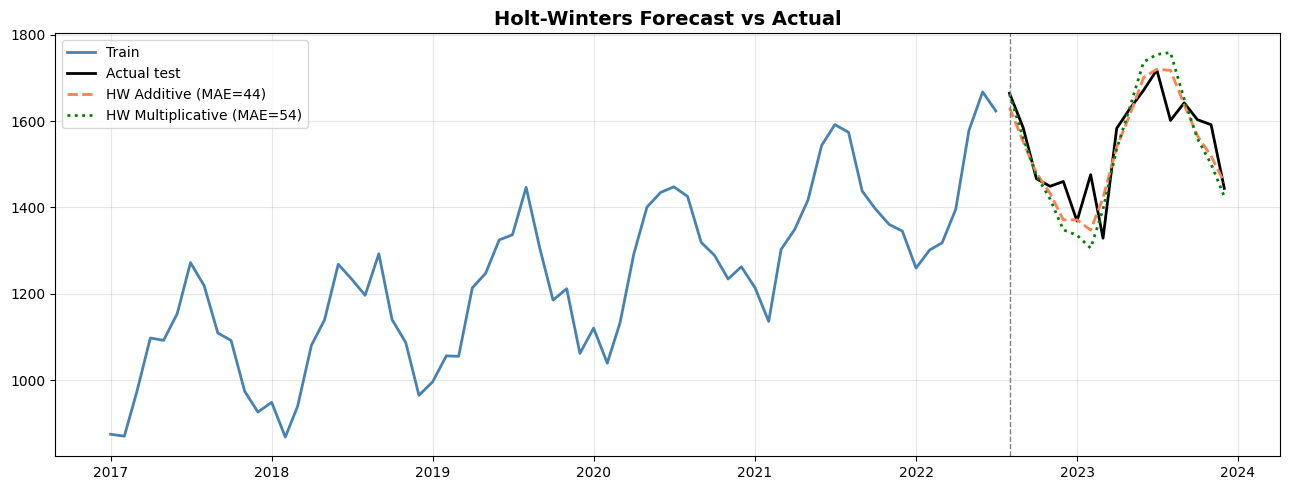

In [4]:
# Holt-Winters (Exponential Triple Smoothing)
# Automatically handles trend + seasonality
hw_add = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
hw_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()

hw_forecast_add = hw_add.forecast(len(test))
hw_forecast_mul = hw_mul.forecast(len(test))

mae_add = mean_absolute_error(test, hw_forecast_add)
mae_mul = mean_absolute_error(test, hw_forecast_mul)
mae_sma = mean_absolute_error(test, sma_forecast(train, test, 12))
mae_naive = mean_absolute_error(test, [train.iloc[-1]]*len(test))  # naive baseline

print('=== Forecast Accuracy Comparison ===')
print(f'  Naive (last value): MAE = {mae_naive:.1f}')
print(f'  SMA (window=12)   : MAE = {mae_sma:.1f}')
print(f'  Holt-Winters (add): MAE = {mae_add:.1f}')
print(f'  Holt-Winters (mul): MAE = {mae_mul:.1f}')

plt.figure(figsize=(13, 5))
plt.plot(train.index, train, color='steelblue', linewidth=2, label='Train')
plt.plot(test.index,  test,  color='black',     linewidth=2, label='Actual test')
plt.plot(test.index, hw_forecast_add, color='coral',  linewidth=2, linestyle='--', label=f'HW Additive (MAE={mae_add:.0f})')
plt.plot(test.index, hw_forecast_mul, color='green',  linewidth=2, linestyle=':',  label=f'HW Multiplicative (MAE={mae_mul:.0f})')
plt.axvline(test.index[0], color='gray', linestyle='--', linewidth=1)
plt.title('Holt-Winters Forecast vs Actual', fontsize=14, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## ✅ Complete!

- **SMA**: simple, interpretable, good baseline — no trend/seasonality handling
- **Holt-Winters**: handles trend AND seasonality — additive or multiplicative
- Always compare against a naive baseline (last value) to confirm your model adds value